In [1]:
import yfinance as yf
import pandas as pd

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [2]:
!pip install --upgrade yfinance


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import requests
import yfinance as yf

session = requests.Session()
session.headers.update({'User-Agent': 'Mozilla/5.0'})

tesla = yf.Ticker('TSLA', session=session)
tesla_data = tesla.history(period='max')
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [5]:
from io import StringIO
import pandas as pd
import requests

tesla_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'

html_data = requests.get(tesla_url).text

# Wrap html_data in StringIO to avoid the FutureWarning
tesla_revenue = pd.read_html(StringIO(html_data), match='Tesla Quarterly Revenue')[
    0
]

tesla_revenue.columns = ['Date', 'Revenue']

tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(
    ',|\$', '', regex=True
)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != '']
tesla_revenue.dropna(inplace=True)

tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


In [6]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603296,1.662209,6892800,0.0,0.0


In [8]:
from io import StringIO
import pandas as pd
import requests

gme_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'

html_data_gme = requests.get(gme_url).text

# Wrap html_data_gme in StringIO to avoid the FutureWarning
gme_revenue = pd.read_html(
    StringIO(html_data_gme), match='GameStop Quarterly Revenue'
)[0]

gme_revenue.columns = ['Date', 'Revenue']

gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace(
    ',|\$', '', regex=True
)
gme_revenue.dropna(inplace=True)

gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


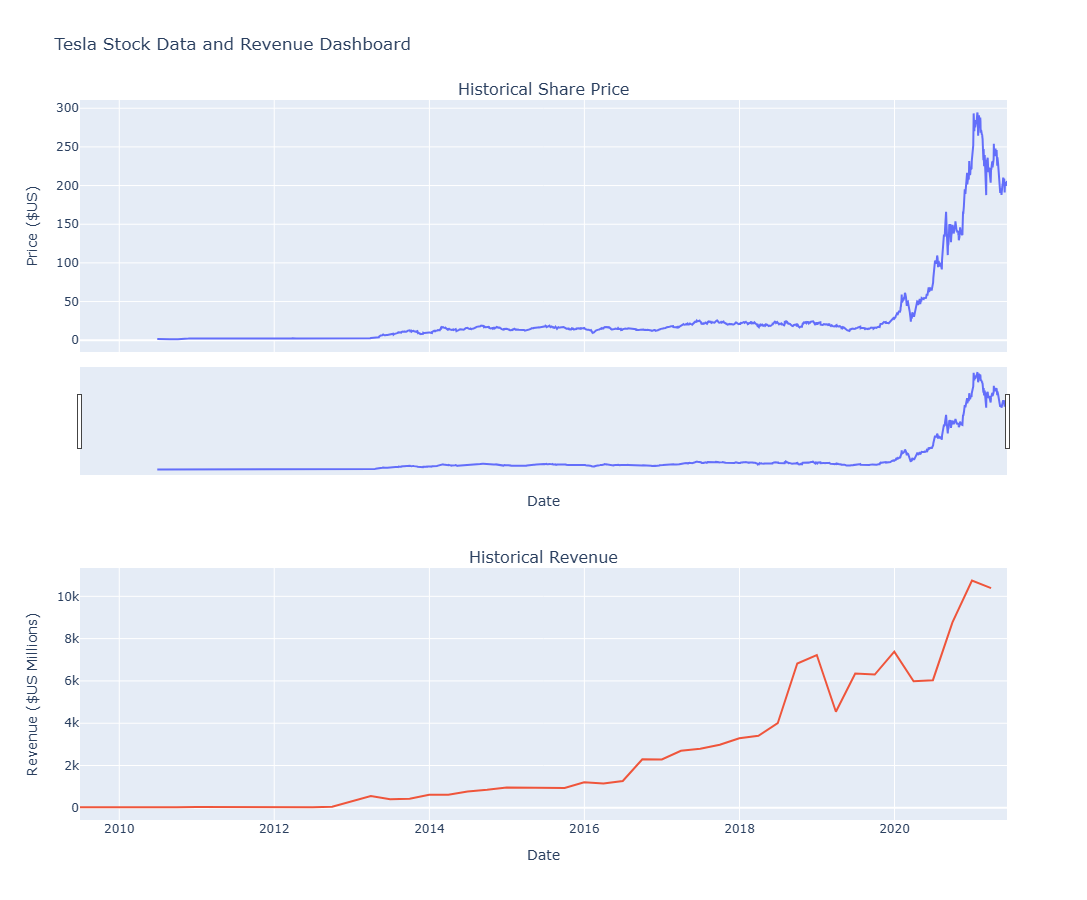

In [9]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def make_graph(stock_data, revenue_data, stock):
  fig = make_subplots(
      rows=2,
      cols=1,
      shared_xaxes=True,
      subplot_titles=("Historical Share Price", "Historical Revenue"),
      vertical_spacing=0.3,
  )
  stock_data_specific = stock_data[stock_data.Date <= "2021-06-14"]
  revenue_data_specific = revenue_data[revenue_data.Date <= "2021-04-30"]

  fig.add_trace(
      go.Scatter(
          x=pd.to_datetime(stock_data_specific.Date),
          y=stock_data_specific.Close.astype("float"),
          name="Share Price",
      ),
      row=1,
      col=1,
  )
  fig.add_trace(
      go.Scatter(
          x=pd.to_datetime(revenue_data_specific.Date),
          y=revenue_data_specific.Revenue.astype("float"),
          name="Revenue",
      ),
      row=2,
      col=1,
  )

  fig.update_xaxes(title_text="Date", row=1, col=1)
  fig.update_xaxes(title_text="Date", row=2, col=1)
  fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
  fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
  fig.update_layout(
      showlegend=False,
      height=900,
      title=stock,
      xaxis_rangeslider_visible=True,
  )
  fig.show()


make_graph(tesla_data, tesla_revenue, "Tesla Stock Data and Revenue Dashboard")

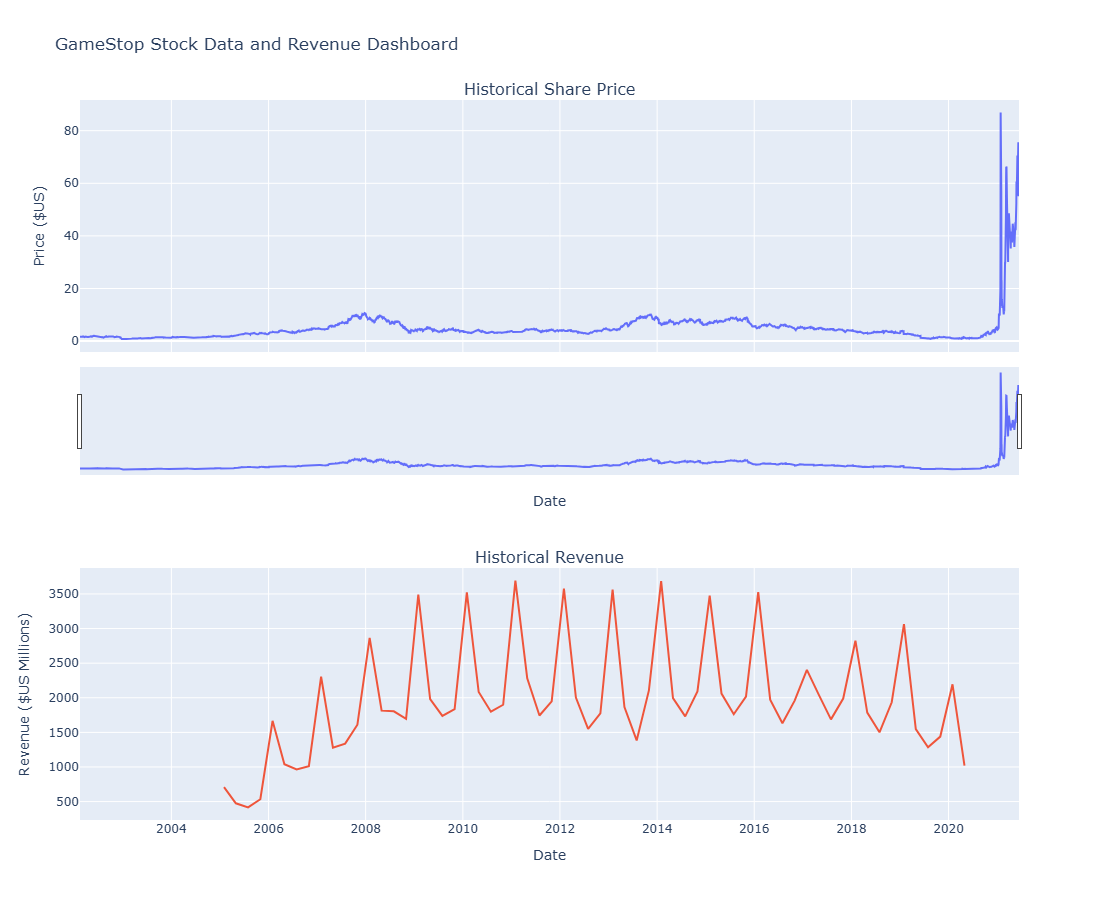

In [10]:
make_graph(gme_data, gme_revenue, "GameStop Stock Data and Revenue Dashboard")